In [7]:
from upsetplot import from_indicators, UpSet
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
intersections = {
    ('Human',): 10,
    ('Animal',): 5,
    ('Environmental',): 3,
    ('Human', 'Animal'): 8,
    ('Human', 'Environmental'): 4,
    ('Animal', 'Environmental'): 2,
    ('Human', 'Animal', 'Environmental'): 12
}

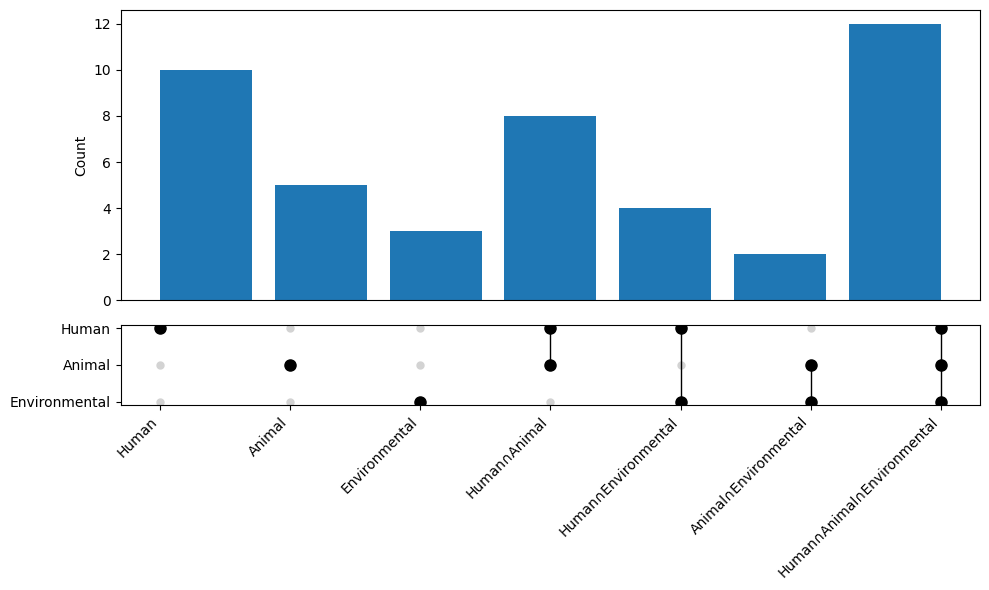

In [8]:
sets = ['Human', 'Animal', 'Environmental']

labels = list(intersections.keys())
counts = list(intersections.values())

fig = plt.figure(figsize=(10, 6))

# Top: intersection sizes
ax_bar = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
ax_bar.bar(range(len(counts)), counts)
ax_bar.set_ylabel("Count")
ax_bar.set_xticks([])

# Bottom: membership matrix
ax_matrix = plt.subplot2grid((4, 1), (3, 0))

for x, combo in enumerate(labels):
    for y, s in enumerate(reversed(sets)):
        if s in combo:
            ax_matrix.plot(x, y, 'ko', markersize=8)
        else:
            ax_matrix.plot(x, y, 'lightgray', marker='o', markersize=5)

    present = [len(sets)-1-i for i, s in enumerate(sets) if s in combo]
    if len(present) > 1:
        ax_matrix.plot([x]*len(present), present, 'k-', lw=1)

ax_matrix.set_yticks(range(len(sets)))
ax_matrix.set_yticklabels(reversed(sets))
ax_matrix.set_xticks(range(len(labels)))
ax_matrix.set_xticklabels(
    ['∩'.join(c) for c in labels],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()